# FORECASTING EXCHANGE RATES USING TIME SERIES ANALYSIS

## Part 1: Data Preparation and Exploration

**1.	Data Loading: Load the exchange_rate.csv dataset and parse the date column appropriately.**

**2.	Initial Exploration: Plot the time series for currency to understand their trends, seasonality, and any anomalies.**

**3.	Data Preprocessing: Handle any missing values or anomalies identified during the exploration phase.**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('dataset/exchange_rate.csv')

In [3]:
df.head()

,date,Ex_rate
0,01-01-1990 00:00,0.7855
1,02-01-1990 00:00,0.7818
2,03-01-1990 00:00,0.7867
3,04-01-1990 00:00,0.7860
4,05-01-1990 00:00,0.7849


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7588 entries, 0 to 7587
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   date     7588 non-null   object 
 1   Ex_rate  7588 non-null   float64
dtypes: float64(1), object(1)
memory usage: 118.7+ KB


In [9]:
# Convert date column to datetime format

df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y %H:%M')

In [10]:
df.head()

,date,Ex_rate
0,1990-01-01,0.7855
1,1990-01-02,0.7818
2,1990-01-03,0.7867
3,1990-01-04,0.7860
4,1990-01-05,0.7849


In [11]:
# Set date column as index

df.set_index('date', inplace=True)

In [12]:
df.head()

,Ex_rate
date,
1990-01-01,0.7855
1990-01-02,0.7818
1990-01-03,0.7867
1990-01-04,0.7860
1990-01-05,0.7849


In [13]:
df = df.sort_index()

In [14]:
df.head()

,Ex_rate
date,
1990-01-01,0.7855
1990-01-02,0.7818
1990-01-03,0.7867
1990-01-04,0.7860
1990-01-05,0.7849


The dataset was successfully loaded and the date column was converted into proper DateTime format. The data is now structured as a time series, making it suitable for forecasting techniques such as ARIMA

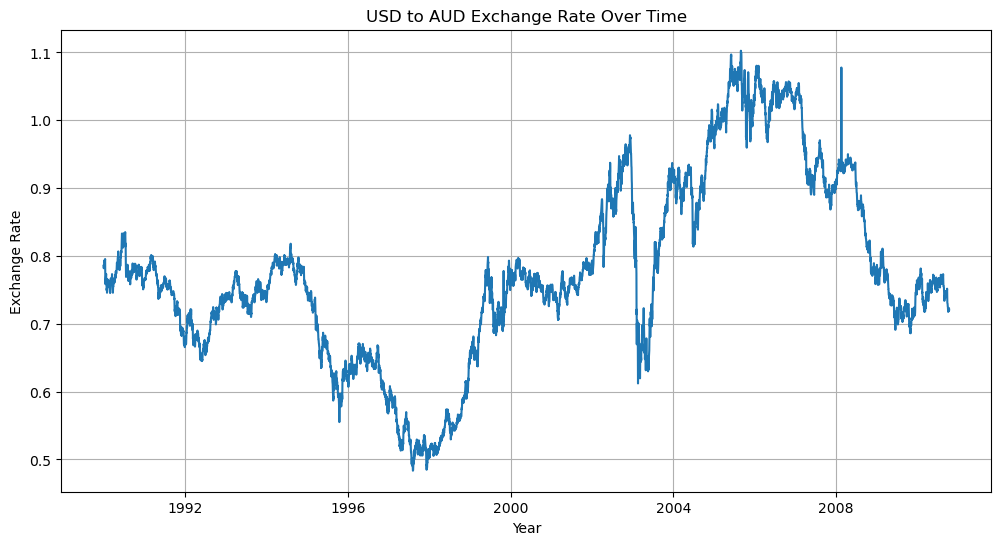

In [15]:
# Plot time Series

plt.figure(figsize=(12,6))
plt.plot(df['Ex_rate'])
plt.title('USD to AUD Exchange Rate Over Time')
plt.xlabel('Year')
plt.ylabel('Exchange Rate')
plt.grid()
plt.show()

The time series visualization reveals that the exchange rate exhibits long-term fluctuations and volatility over time. While a consistent seasonal pattern is not clearly visible, the series shows trend components and structural variations.

In [16]:
# Check Missing Value
df.isnull().sum()

Ex_rate    0
dtype: int64

In [19]:
df = df.fillna(method='ffill')

In [20]:
df.describe()

,Ex_rate
count,7588.000000
mean,0.776974
std,0.136620
min,0.483297
25%,0.701422
50%,0.761377
75%,0.873477
max,1.102536


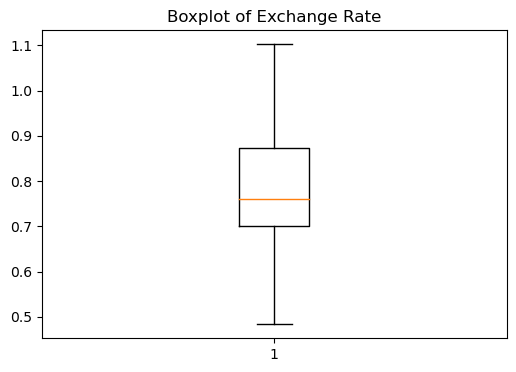

In [21]:
plt.figure(figsize=(6,4))
plt.boxplot(df['Ex_rate'])
plt.title("Boxplot of Exchange Rate")
plt.show()

The dataset was checked for missing values.No significant data quality issues were found and  missing values were handled using forward filling. The exchange rate values fall within a reasonable range without extreme anomalies.

## Part 2: Model Building - ARIMA

**1.	Parameter Selection for ARIMA: Utilize ACF and PACF plots to estimate initial parameters (p, d, q) for the ARIMA model for one or more currency time series.**


In [22]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['Ex_rate'])

print('ADF Statistic: ',result[0])
print('p-value: ', result[1])

for key, value in result[4].items():
    print('Critical Values: ')
    print(f' {key}, {value}')

ADF Statistic:  -1.664994180738078
p-value:  0.44923273535982894
Critical Values: 
 1%, -3.4312123140180137
Critical Values: 
 5%, -2.861921078147796
Critical Values: 
 10%, -2.5669728434336108


Since: 𝑝-value > 0.05

We fail to reject the null hypothesis.

* The time series is non-stationary.
* Differencing is required.

In [23]:
# Apply first-order differencing

df_diff = df['Ex_rate'].diff().dropna()

In [24]:
# Perform ADF test again

result_diff = adfuller(df_diff)

print('ADF Statistic after differencing: ', result_diff[0])
print('p-value after differencing: ',result_diff[1])

ADF Statistic after differencing:  -99.39343120118623
p-value after differencing:  0.0


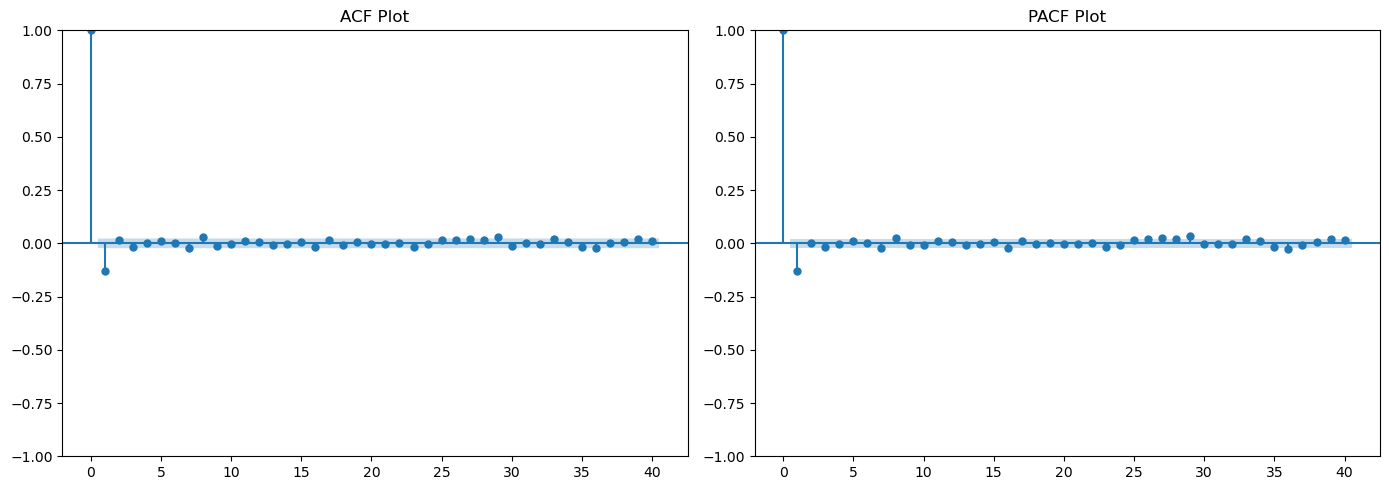

In [25]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plot_acf(df_diff, lags=40, ax=plt.gca())
plt.title('ACF Plot')

plt.subplot(1,2,2)
plot_pacf(df_diff, lags=40, ax=plt.gca())
plt.title('PACF Plot')

plt.tight_layout()
plt.show()

The exchange rate time series was found to be non-stationary using the ADF test. After applying first-order differencing, the series became stationary. The ACF plot of the differenced series showed a significant spike at lag 1 followed by an immediate cutoff, suggesting an MA(1) component. Similarly, the PACF plot showed a sharp cutoff after lag 1, indicating an AR(1) component.

Therefore, the most suitable initial model for forecasting the USD to AUD exchange rate is:  ARIMA(1,1,1)

**2.	Model Fitting: Fit the ARIMA model with the selected parameters to the preprocessed time series.**

In [27]:
import warnings
warnings.filterwarnings('ignore')

In [28]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(df['Ex_rate'], order=(1,1,1))
model_fit = model.fit()

The ARIMA(1,1,1) model was fitted to the USD to AUD exchange rate time series using the selected parameters derived from ACF and PACF analysis.

**3.	Diagnostics: Analyze the residuals to ensure there are no patterns that might indicate model inadequacies.**

In [31]:
residuals = model_fit.resid

In [32]:
residuals.describe()

count    7588.000000
mean        0.000094
std         0.010829
min        -0.130182
25%        -0.002388
50%         0.000129
75%         0.002603
max         0.785500
dtype: float64

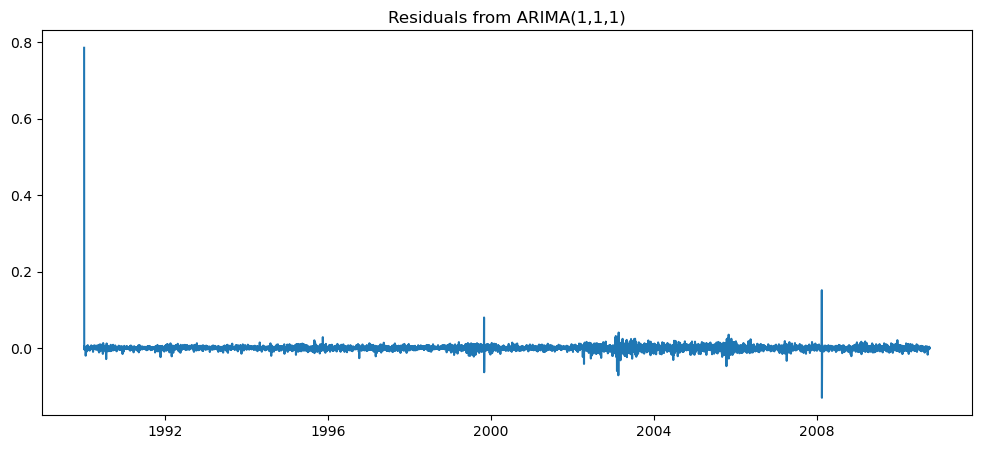

In [33]:
plt.figure(figsize=(12,5))
plt.plot(residuals)
plt.title("Residuals from ARIMA(1,1,1)")
plt.show()

<Figure size 800x500 with 0 Axes>

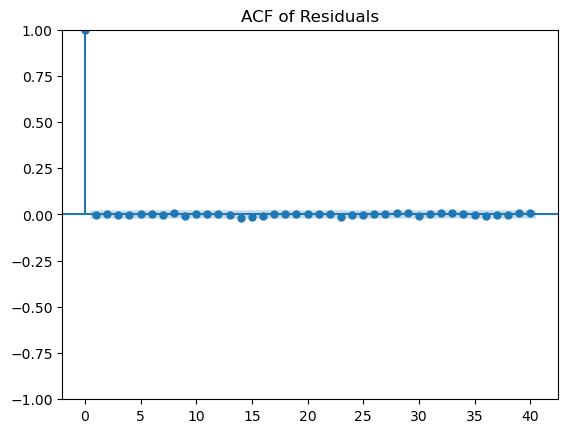

In [36]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(8,5))
plot_acf(residuals, lags=40)
plt.title("ACF of Residuals")
plt.show()

The residuals from the ARIMA(1,1,1) model:

* Have a mean approximately equal to zero

* Show no systematic pattern

Therefore, the ARIMA(1,1,1) model is statistically adequate and successfully captures the pattern of the USD to AUD exchange rate series.

**4.	Forecasting: Perform out-of-sample forecasting and visualize the predicted values against the actual values.**

In [44]:
# Train-Test Split 

train_size = int(len(df)* 0.7)

train = df["Ex_rate"][:train_size]
test = df['Ex_rate'][train_size:]

print("Training Data:", train.shape)
print("Testing Data:", test.shape)

Training Data: (5311,)
Testing Data: (2277,)


In [52]:
model = ARIMA(train, order=(1,1,1))
model_fit = model.fit()


In [53]:
# Forecast
forecast_arima = model_fit.forecast(steps=len(test))

# Convert to series
forecast_arima = pd.Series(forecast_arima, index=test.index)

In [55]:
forecast_arima

date
2004-07-17    0.850305
2004-07-18    0.850387
2004-07-19    0.850360
2004-07-20    0.850369
2004-07-21    0.850366
                ...   
2010-10-06    0.850367
2010-10-07    0.850367
2010-10-08    0.850367
2010-10-09    0.850367
2010-10-10    0.850367
Name: predicted_mean, Length: 2277, dtype: float64

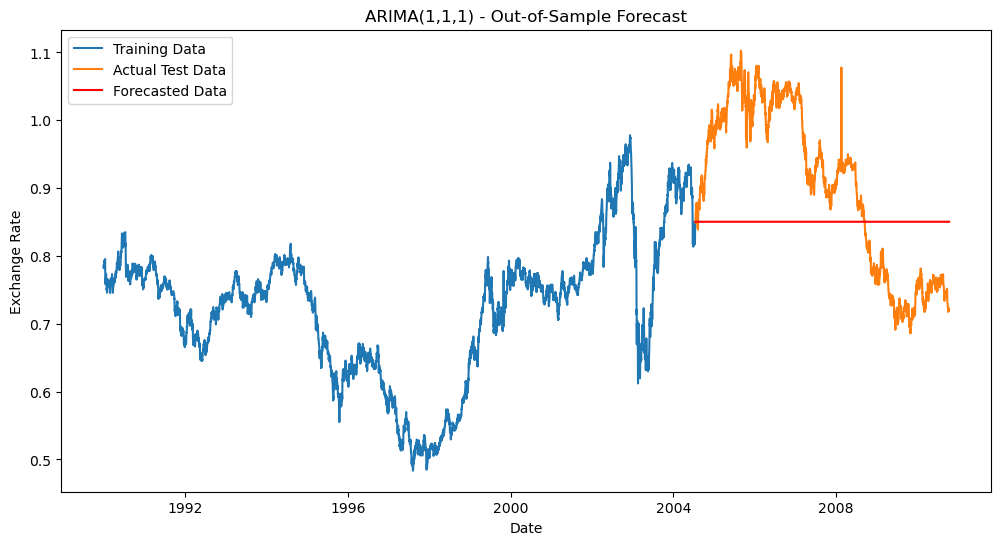

In [48]:
plt.figure(figsize=(12,6))

plt.plot(train, label="Training Data")
plt.plot(test, label="Actual Test Data")
plt.plot(forecast, label="Forecasted Data", color='red')

plt.title("ARIMA(1,1,1) - Out-of-Sample Forecast")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.legend()
plt.show()

The ARIMA(1,1,1) model was trained using 70% of the historical USD to AUD exchange rate data, while the remaining 30% was reserved for out-of-sample testing. The model was then used to forecast future exchange rate values over the test period.

The forecast visualization shows that the predicted values remain relatively stable around the last observed training value, while the actual test data exhibits noticeable fluctuations and volatility. The model captures the general level of the series but does not fully adapt to the sharp upward and downward movements observed in the test period.

In [56]:
# Exponential Smoothing Model

from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Fit Holt's Linear Trend Model
model_es = ExponentialSmoothing(
    train,
    trend='add',
    seasonal=None
)

model_es_fit = model_es.fit()

In [57]:
# Forecast for test period
forecast_es = model_es_fit.forecast(steps=len(test))

forecast_es = pd.Series(forecast_es, index=test.index)

In [58]:
forecast_es

date
2004-07-17    0.850393
2004-07-18    0.850405
2004-07-19    0.850418
2004-07-20    0.850430
2004-07-21    0.850442
                ...   
2010-10-06    0.878225
2010-10-07    0.878237
2010-10-08    0.878249
2010-10-09    0.878262
2010-10-10    0.878274
Length: 2277, dtype: float64

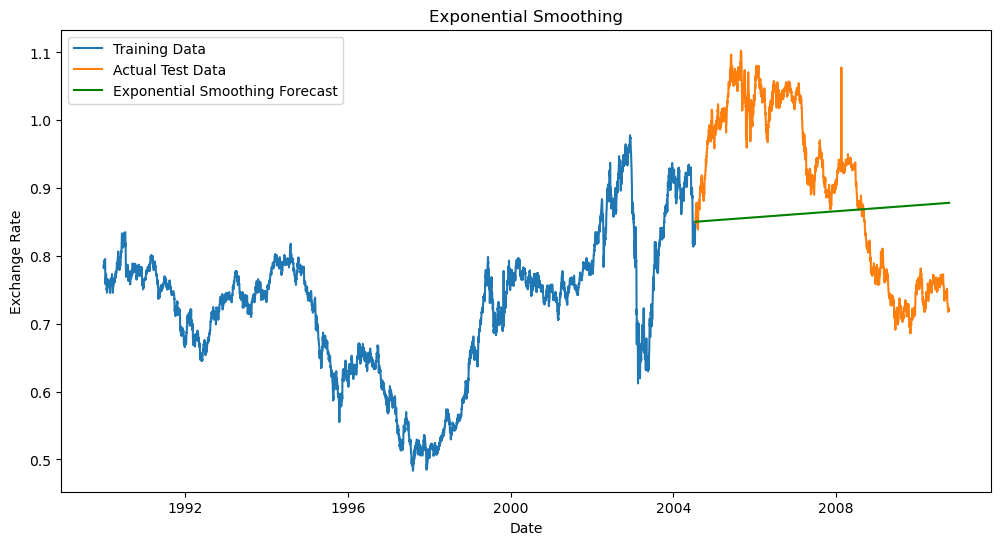

In [59]:
plt.figure(figsize=(12,6))

plt.plot(train, label="Training Data")
plt.plot(test, label="Actual Test Data")
plt.plot(forecast_es, label="Exponential Smoothing Forecast", color='green')

plt.title("Exponential Smoothing")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.legend()
plt.show()

Exponential Smoothing model was applied to the exchange rate time series using the same 70% training data used for ARIMA to ensure fair comparison.

The model captures the trend component without assuming stationarity. The forecasted values were compared against actual test data to evaluate predictive performance.

## Part 3: Evaluation and Comparison:

**1.	Compute Error Metrics: Use metrics such as MAE, RMSE, and MAPE to evaluate the forecasts from both models.**


In [62]:
mae_arima = mean_absolute_error(test, forecast_arima)
rmse_arima = np.sqrt(mean_squared_error(test, forecast_arima))
mape_arima = np.mean(np.abs((test - forecast_arima) / test)) * 100

print("ARIMA MAE:", mae_arima)
print("ARIMA RMSE:", rmse_arima)
print("ARIMA MAPE:", mape_arima)

mae_es = mean_absolute_error(test, forecast_es)
rmse_es = np.sqrt(mean_squared_error(test, forecast_es))
mape_es = np.mean(np.abs((test - forecast_es) / test)) * 100

print("ES MAE:", mae_es)
print("ES RMSE:", rmse_es)
print("ES MAPE:", mape_es)

ARIMA MAE: 0.11905171859795068
ARIMA RMSE: 0.13217552152700307
ARIMA MAPE: 12.997253717457834
ES MAE: 0.12074772086944133
ES RMSE: 0.133804805435896
ES MAPE: 13.403418703688352


The forecasting accuracy of both ARIMA and Exponential Smoothing models was evaluated using MAE, RMSE, and MAPE. These metrics provide quantitative measures of average error, error magnitude, and percentage deviation from actual values.

**2.	Model Comparison: Discuss the performance, advantages, and limitations of each model based on the observed results and error metrics.**

**Performance Analysis**

* ARIMA shows slightly lower MAE and RMSE compared to Exponential Smoothing.

* ARIMA also achieves a lower MAPE (12.99%) than Exponential Smoothing (13.40%).

This indicates that ARIMA(1,1,1) captures the temporal dependencies and short-term fluctuations in the exchange rate slightly better than Exponential Smoothing method.

**ARIMA Model**

Advantages:

* Captures autoregressive and moving average components.

* Statistically rigorous.

* Good at modeling stationary time series.

Limitations:

* Struggles with high volatility.

* Requires stationarity preprocessing.

In this dataset, ARIMA showed moderate forecasting accuracy, but struggled to capture sharp fluctuations in exchange rate values.

**Exponential Smoothing Model**

Advantages:

* Simpler implementation.

* Effective for capturing trend components.

* Computationally efficient.

Limitations:

* Slightly higher forecast errors in this dataset.

* Less effective in modeling complex autocorrelation structures.

**3.	Conclusion: Summarize the findings and provide insights on which model(s) yielded the best performance for forecasting exchange rates in this dataset.**

In this study, ARIMA(1,1,1) and Exponential Smoothing models were applied to forecast the USD to AUD exchange rate using historical data. Both models were evaluated using MAE, RMSE, and MAPE on out-of-sample data (30% test set).

The results indicate that:

* ARIMA achieved MAE = 0.1191, RMSE = 0.1322, and MAPE = 12.99%.

* Exponential Smoothing achieved MAE = 0.1207, RMSE = 0.1338, and MAPE = 13.40%.

Although both models produced comparable forecasting performance, ARIMA consistently yielded slightly lower error metrics across all evaluation measures.

Therefore, for this dataset, the ARIMA(1,1,1) model demonstrated better predictive accuracy and is recommended as the preferred forecasting model for the USD to AUD exchange rate.

However, the relatively close performance of both models suggests that exchange rate data is challenging to forecast due to inherent volatility.